## Logistic Regression - Insurance dataset

Categorical data: 0 = did not buy insurance, 1 = bought insurance

Target variable: bought_insurance

Simple dataset with 27 rows

Goal: Use logistic regression to predict whether a specific age will buy insurance

Result: 100% accuracy with a test split of 0.1

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [44]:
#load model
df = pd.read_csv("insurance_data.csv")
df

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


In [45]:
#check rows/columns
df.shape

(27, 2)

In [46]:
#check empty values
df.isnull().sum()

age                 0
bought_insurance    0
dtype: int64

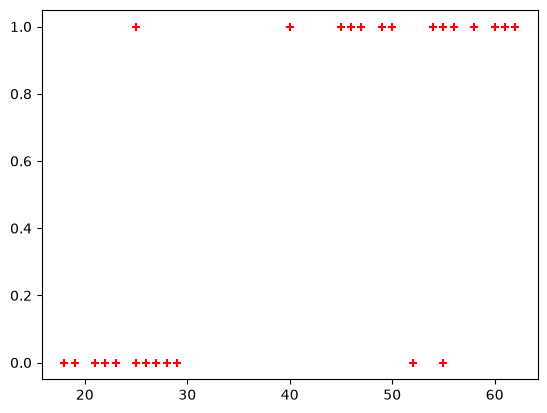

In [47]:
# Visualization
%matplotlib inline
plt.scatter(df.age, df.bought_insurance, color = 'red', marker = '+')

Observations

There seems to be a clear distinction between the two categories. Lower ages are more likely to not buy insurance, while higher ages are more likely to buy insurance. This makes logistic regression a good model for this dataset.

In [48]:
#train/ split
X = df[["age"]]
y= df.drop("age", axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)

In [49]:
X_test

,age
8,62
13,29
9,61


In [50]:
#Training Logistic model
model = LogisticRegression()
model.fit(X_train, y_train)
model.predict(X_test)

C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1, 0, 1])

In [51]:
#comparing the output to the test predictions output
y_test

,bought_insurance
8,1
13,0
9,1


Observation
The model is performing as expected. Lower ages are predicted as less likely to buy insurance, while older ages are predicted as more likely to buy insurance.

In [52]:
model_accuracy = model.score(X_test, y_test)
model_accuracy

1.0

In [53]:
#checking mdoesl progbility aginst the boudary of 0.5
model.predict_proba(X_test)

array([[0.04794177, 0.95205823],
       [0.77002692, 0.22997308],
       [0.05409225, 0.94590775]])